# Module imports

In [1]:
from pathlib import Path
import jax.numpy as np
from jax import config
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import (
    get_agn_lensed_parameters,
    get_agn_lens_angles,
    PML_time_delay_magnification,
    dLGridGlob, zGridGlob, einstein_angle
)

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


# Function definitions

In [2]:
def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota']    = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase']   = np.zeros_like(mag_1)  # No change in phi
    output_params['delta_psi']     = np.zeros_like(mag_1)  # No change in psi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in mass
    return output_params

In [3]:
def convert_y_to_src_pos(y, R_orbit, rs=1):
    # Convert source position from units of Einstein radius to units of R_orbit
    # Returns a 2D grid of src_pos with shape (len(y), len(R_orbit))
    Dls_min = (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs # for rs=1, this is in units of R_S
    theta_E = np.sqrt(2 * Dls_min) # Einstein radius in units of R_S
    src_pos = np.outer(y, theta_E / R_orbit)
    return src_pos

# Detector setup

In [4]:
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')

wf_model = waveforms.IMRPhenomD()

L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


# Generate waveforms

## Parameters

In [5]:
# Define event parameters
events = {
    'Mc': 50, 'eta': 0.1, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.2,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.float64(val) for key, val in events.items()}

general_lensed_params = L1_AGN.convert_to_general_lensed_parameters(events)
simple_lensed_params = PML_simple_lens_parameters(events)

only_rel_mass_params = general_lensed_params.copy()
only_rel_mass_params['Mc'] = events['Mc']

## Injection

In [6]:
# Waveform metadata
sampling_frequency = 2048.  # Hz
duration = 8.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]

cplx_zeros = np.zeros((freq_array.size,), dtype=np.complex128)
# Make use of jax numpy `.at.set` copying feature
full_AGN_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_arr, general_lensed_params))
simple_lensed_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_arr, simple_lensed_params))
only_rel_mass_strain = cplx_zeros.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_arr, only_rel_mass_params))

psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)

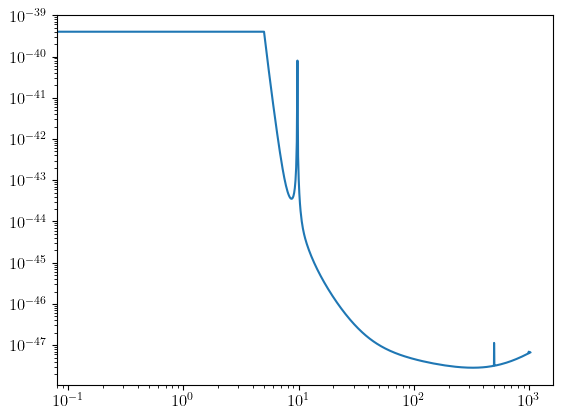

In [7]:
plt.loglog(freq_array, psd_interp)

## Whiten

In [8]:
def whitened_TD_strain(FD_strain):
    whitened_FD = FD_strain / np.sqrt(psd_interp * duration / 4)
    whitened_TD = np.fft.irfft(whitened_FD) 
    window_factor = len(freq_mask) / np.sqrt(np.sum(freq_mask))
    return whitened_TD * window_factor

In [9]:
TD_full_AGN_strain_whitened = whitened_TD_strain(full_AGN_strain)
TD_simple_lensed_strain_whitened = whitened_TD_strain(simple_lensed_strain)
TD_only_rel_mass_strain_whitened = whitened_TD_strain(only_rel_mass_strain)

In [ ]:
full_AGN_strain_whitened = full_AGN_strain / np.sqrt(psd_interp)
simple_lensed_strain_whitened = simple_lensed_strain / np.sqrt(psd_interp)
only_rel_mass_strain_whitened = only_rel_mass_strain / np.sqrt(psd_interp)

## Convert to time series

In [9]:
TD_full_AGN_strain_whitened = np.fft.irfft(full_AGN_strain_whitened) * sampling_frequency
TD_simple_lensed_strain_whitened = np.fft.irfft(simple_lensed_strain_whitened) * sampling_frequency
TD_only_rel_mass_strain_whitened = np.fft.irfft(only_rel_mass_strain_whitened) * sampling_frequency

## Plot whitened waveforms

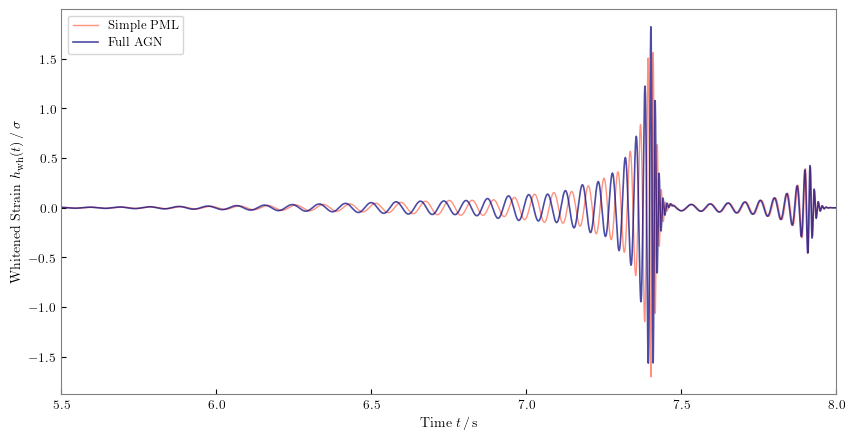

In [12]:
post_merger_time = -0.6
n_index = int(post_merger_time * sampling_frequency)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_array, np.roll(TD_simple_lensed_strain_whitened, n_index), 
        label='Simple PML', alpha=0.7, c='tomato', linewidth=1)
ax.plot(time_array, np.roll(TD_full_AGN_strain_whitened, n_index), 
        label='Full AGN', alpha=0.7, c='navy', linewidth=1.2)
# ax.plot(time_array, np.roll(TD_only_rel_mass_strain_whitened, n_index), label='Only relative mass change')
ax.set_xbound(5.5, 8)
ax.set_xlabel(r'Time $t\,/\,{\rm s}$')
ax.set_ylabel(r'Whitened Strain $h_{\rm wh}(t)\,/\,\sigma$')
ax.legend(loc='upper left')

In [11]:
plus_image_params, minus_image_params = get_agn_lensed_parameters(events)
dL_plus = plus_image_params['dL']
dL_minus = minus_image_params['dL']
dL_plus / dL_minus

Array(0.25448485, dtype=float64)

In [12]:
plus_image_params['tcoal'], minus_image_params['tcoal']

(Array(0., dtype=float64), Array(-5.87223803e-06, dtype=float64))

In [13]:
minus_image_params['tcoal'] * 24 * 3600

Array(-0.50736137, dtype=float64)